In [1]:
!pip install python-Levenshtein

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.enhancements.srl import annotate_dataset_with_srl
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "srl"
inject_roles = True
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
paths = get_dataset_paths(enhancement)

annotate_dataset_with_srl(paths["train"], paths["train"])
annotate_dataset_with_srl(paths["dev"], paths["dev"])

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)

[INFO] Dataset saved to: data/srl/train.tsv
[INFO] Dataset saved to: data/srl/dev.tsv


In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

[DEBUG] srl Train Loss (Epoch 1): 1.4630
[DEBUG] srl Dev Eval (Epoch 1):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0019
  edit_distance_avg: 181.6200
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.0933
[DEBUG] srl Train Loss (Epoch 2): 0.9581
[DEBUG] srl Dev Eval (Epoch 2):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0017
  edit_distance_avg: 133.0233
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.4667
[DEBUG] srl Train Loss (Epoch 3): 0.7245
[DEBUG] srl Dev Eval (Epoch 3):
  precision: 0.0100
  recall: 0.0036
  f1: 0.0052
  bleu: 0.0126
  edit_distance_avg: 120.8600
  predicate_accuracy: 0.0120
  valid_logical_form_ratio: 0.9000
[DEBUG] srl Train Loss (Epoch 4): 0.5579
[DEBUG] srl Dev Eval (Epoch 4):
  precision: 0.2667
  recall: 0.1549
  f1: 0.1872
  bleu: 0.1531
  edit_distance_avg: 114.5533
  predicate_accuracy: 0.1571
  valid_logical_form_ratio: 0.9733
[DEBUG] srl Train Loss (Epoch 5): 0.4426
[DEBUG] srl Dev Eval (Epoch 5):

[INFO] Predictions saved to: predictions/srl/t5-small_test_predictions.txt
[INFO] Metrics saved to: results/srl/t5-small_test_metrics.csv
[DEBUG] srl Test Eval:
  precision: 0.5431
  recall: 0.4719
  f1: 0.4744
  bleu: 0.1946
  edit_distance_avg: 117.3933
  predicate_accuracy: 0.4598
  valid_logical_form_ratio: 0.9867


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.5431,0.4719,0.4744,0.1946,117.3933,0.4598,0.9867


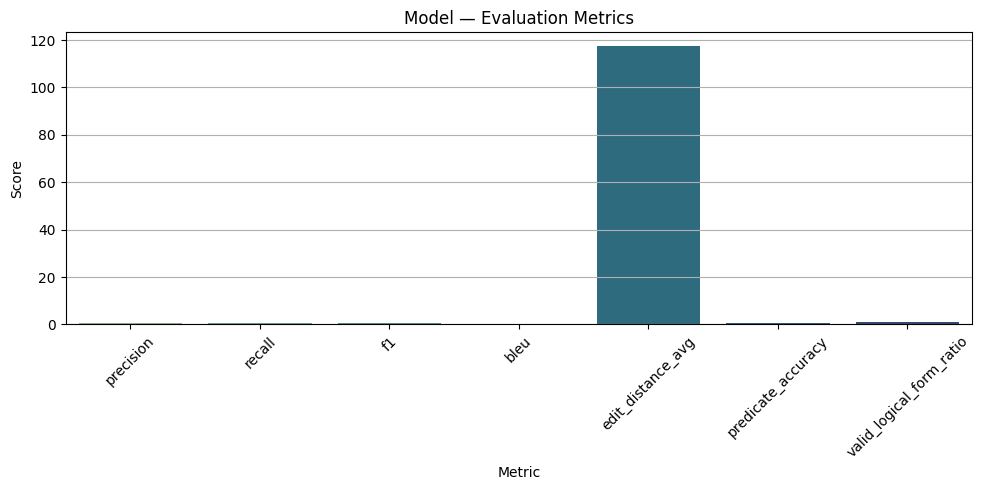

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(f"results/{enhancement}/{model_name}_test_metrics.csv")
plot_metrics_bar(f"results/{enhancement}/{model_name}_test_metrics.csv")

[INFO] Predictions saved to: predictions/srl/t5-small_gen_predictions.txt
[INFO] Metrics saved to: results/srl/t5-small_gen_metrics.csv
[DEBUG] srl Gen Eval:
  precision: 0.0875
  recall: 0.0458
  f1: 0.0574
  bleu: 0.0587
  edit_distance_avg: 158.4648
  predicate_accuracy: 0.0692
  valid_logical_form_ratio: 0.5890


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.0875,0.0458,0.0574,0.0587,158.4648,0.0692,0.5890


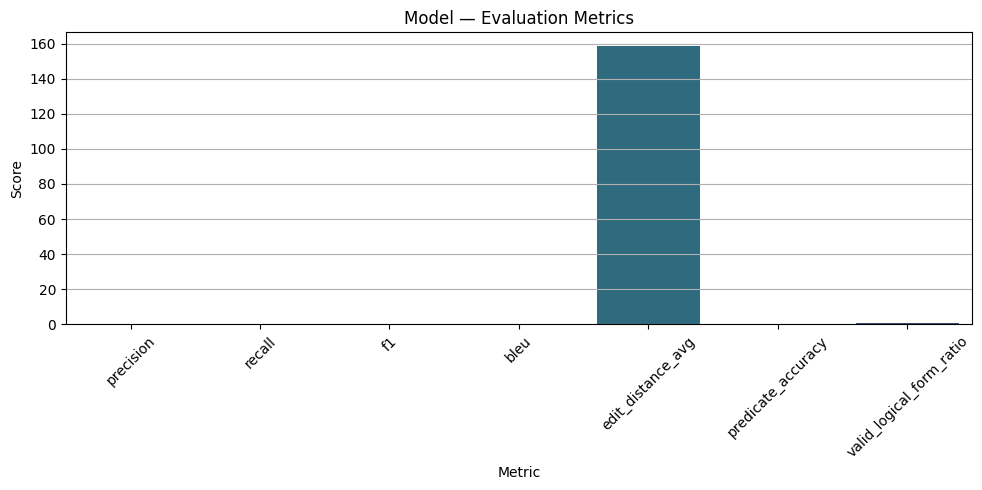

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(f"results/{enhancement}/{model_name}_gen_metrics.csv")
plot_metrics_bar(f"results/{enhancement}/{model_name}_gen_metrics.csv")

,Test,Gen
precision,0.5431,0.0875
recall,0.4719,0.0458
f1,0.4744,0.0574
bleu,0.1946,0.0587
edit_distance_avg,117.3933,158.4648
predicate_accuracy,0.4598,0.0692
valid_logical_form_ratio,0.9867,0.5890


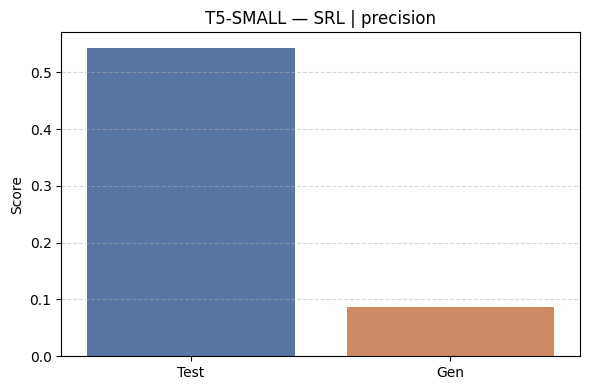

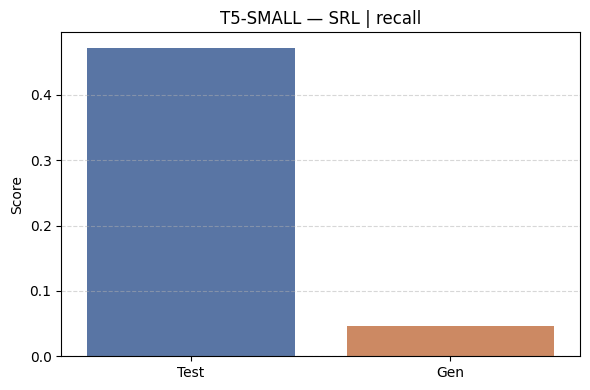

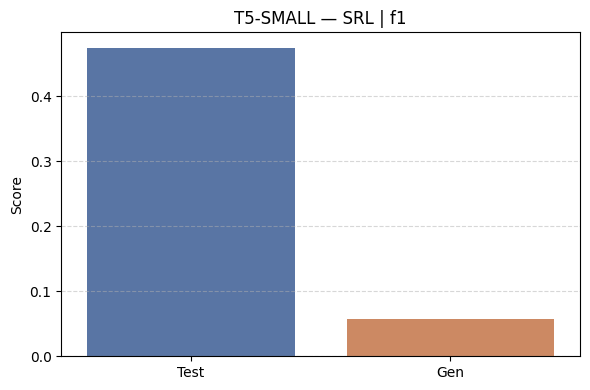

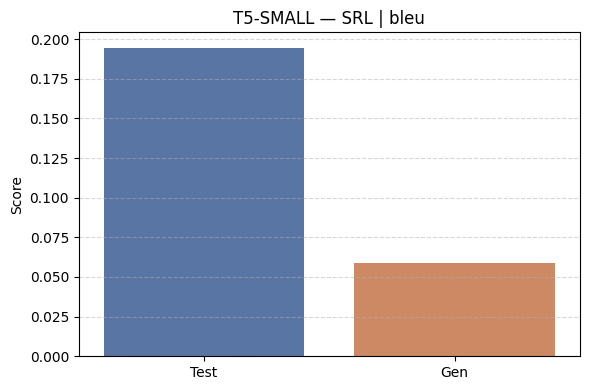

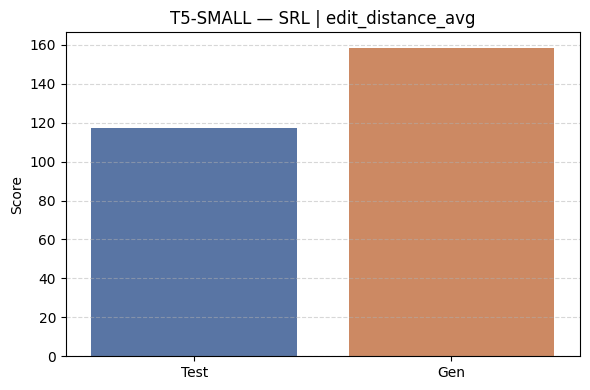

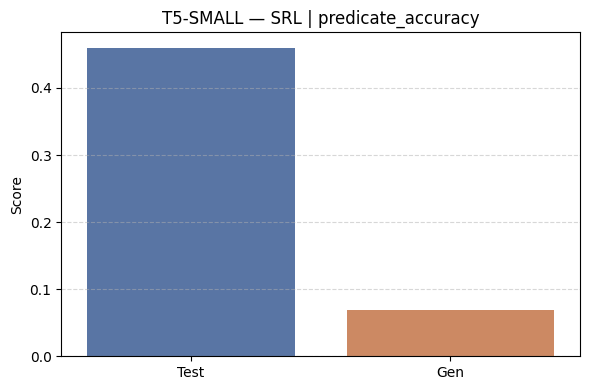

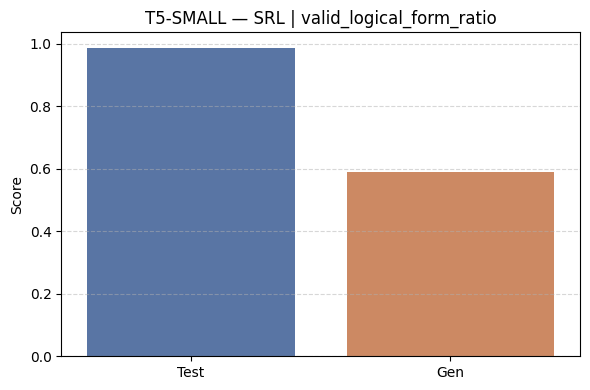

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)